# A Coprime-Decimation Fast Fourier Transform for Sub-Linear Sparse-Support Estimation

### Abstract

Locating the support of a sparse spectrum — the small set of frequencies at which a length-$N$ signal has non-negligible energy — does not, in principle, require computing the full $N$-point spectrum. This notebook derives an algorithm that recovers the support using only two short discrete Fourier transforms, of lengths $N_1$ and $N_2$ with $N_1N_2=N$ and $\gcd(N_1,N_2)=1$, obtained by *decimating* (subsampling) the time-domain signal at each of the two coprime rates. The derivation proceeds from a decimation (aliasing) theorem, which is then specialized to a coprime pair chosen so that $N_1,N_2 = \Theta(\sqrt{N})$, yielding an algorithm of time complexity $O(\sqrt{N}\log\sqrt{N})$ that accesses only $O(\sqrt{N})$ of the $N$ input samples. The method is shown to recover a single active frequency exactly and unambiguously; the notebook then examines, with an explicit numerical example, the collision ("ghost") phenomenon that arises when more than one frequency is active, and discusses its implications.

## 1. Introduction

A companion notebook derived the Good–Thomas prime-factor algorithm (PFA), which computes a *complete* length-$N$ DFT, for $N=N_1N_2$ coprime, as a two-dimensional array of length-$N_1$ and length-$N_2$ transforms, at a total cost of $O(N_1N_2\cdot(\text{sub-transform cost}))$ — asymptotically $O(N\log N)$ once fast sub-transforms are used, but still requiring every one of the $N$ input samples to be read and processed.

When the spectrum is known to be **sparse**, this is wasteful: if only $K \ll N$ frequencies are active, locating them should not require touching all $N$ samples. This notebook derives an algorithm that computes only **two** short transforms — of lengths $N_1$ and $N_2$ — obtained by decimating the *time-domain* signal, rather than reshaping it into an $N_1\times N_2$ array. Choosing the coprime factors so that $N_1,N_2=\Theta(\sqrt N)$, and evaluating each short transform with a fast algorithm (radix-2 or Bluestein, from companion notebooks), gives an overall running time of

$$
O\big(\sqrt N \log \sqrt N\big),
$$

using only $O(\sqrt N)$ of the $N$ available samples. Section 2 reviews the required preliminaries. Section 3 derives the decimation (aliasing) theorem that underlies the method. Section 4 specializes this theorem to a coprime pair and derives the support-estimation algorithm, including a precise statement of when its recovery is exact. Section 5 depicts the resulting computational structure. Sections 6–7 provide an implementation and numerical verification, including empirical timing. Section 8 discusses the method's limitations.

## 2. Preliminaries

### 2.1 The Discrete Fourier Transform

For $x[0],\dots,x[N-1]$, the DFT and its inverse are

$$
X[k] = \sum_{n=0}^{N-1} x[n]\,W_N^{kn}, \qquad x[n] = \frac{1}{N}\sum_{k=0}^{N-1} X[k]\,W_N^{-kn}, \qquad W_N \triangleq e^{-i2\pi/N}. \tag{1}
$$

### 2.2 Decimation (Downsampling)

Let $N = DM$. The length-$M$ sequence obtained by retaining every $D$-th sample of $x$,

$$
y[m] \triangleq x[Dm], \qquad m = 0,\dots,M-1, \tag{2}
$$

is the **decimation of $x$ by $D$**. Only $M=N/D$ of the $N$ samples of $x$ are used in forming $y$.

### 2.3 The Chinese Remainder Theorem

As derived in the companion notebook on the prime-factor algorithm: for coprime $N_1,N_2$ with $N=N_1N_2$, Bézout's identity gives integers $u,v$ with $uN_1+vN_2=1$; defining the idempotents $e_1 \triangleq (vN_2)\bmod N$ and $e_2 \triangleq (uN_1)\bmod N$, the unique integer in $\{0,\dots,N-1\}$ congruent to $k_1 \pmod {N_1}$ and $k_2 \pmod{N_2}$ is

$$
k(k_1,k_2) = (k_1e_1 + k_2e_2) \bmod N. \tag{3}
$$

## 3. The Decimation (Aliasing) Theorem

**Proposition.** Let $N=DM$ and let $y[m]=x[Dm]$, $m=0,\dots,M-1$, per Equation (2). Then the $M$-point DFT of $y$ satisfies

$$
Y[k] = \frac{1}{D}\sum_{r=0}^{D-1} X[k+rM], \qquad k = 0,\dots,M-1. \tag{4}
$$

That is, each output of the short, $M$-point transform of the decimated signal equals the average of $D$ values of the full $N$-point spectrum, spaced $M$ apart.

*Proof.* Using the inverse-DFT relation of Equation (1) to express $x[Dm]$ in terms of $X$,

$$
y[m] = x[Dm] = \frac{1}{N}\sum_{k'=0}^{N-1} X[k']\, W_N^{-k'Dm} = \frac{1}{N}\sum_{k'=0}^{N-1} X[k']\, e^{\,i2\pi k' m/M}, \tag{5}
$$

where $W_N^{-Dm} = e^{i2\pi Dm/N} = e^{i2\pi m/M}$ was used. Since $e^{i2\pi k' m/M}$ depends on $k'$ only through $k' \bmod M$, group the sum over $k'=0,\dots,N-1$ into $M$ residue classes, writing $k' = k+rM$ for $k=0,\dots,M-1$ and $r=0,\dots,D-1$:

$$
y[m] = \frac{1}{N}\sum_{k=0}^{M-1} e^{\,i2\pi km/M} \underbrace{\sum_{r=0}^{D-1} X[k+rM]}_{\textstyle \triangleq\, S[k]}. \tag{6}
$$

Equation (6) expresses $y$ as (a scaled version of) the length-$M$ inverse DFT of $S$. Taking the forward $M$-point DFT of both sides and using the orthogonality relation $\sum_{m=0}^{M-1} e^{i2\pi(k-k'')m/M} = M$ if $k=k''$ and $0$ otherwise (the same relation used in the convolution theorem of the companion notebook),

$$
Y[k] = \sum_{m=0}^{M-1} y[m]\,e^{-i2\pi km/M} = \frac{1}{N}\sum_{k''=0}^{M-1} S[k'']\sum_{m=0}^{M-1} e^{i2\pi(k''-k)m/M} = \frac{M}{N}\,S[k] = \frac{S[k]}{D}, \tag{7}
$$

using $N=DM$. Equation (7) is precisely Equation (4). $\blacksquare$

Equation (4) is the discrete analogue of the classical aliasing relationship between time-domain sampling and frequency-domain periodic repetition: decimating in time by $D$ causes the spectrum to fold onto itself $D$-fold.

## 4. Coprime Decimation for Sparse Support Estimation

### 4.1 Two Decimated Transforms

Let $N=N_1N_2$ with $\gcd(N_1,N_2)=1$. Applying Equation (4) with $D=N_1$, $M=N_2$ to obtain $y_1[m_1]=x[N_1m_1]$, and separately with $D=N_2$, $M=N_1$ to obtain $y_2[m_2]=x[N_2m_2]$,

$$
Y_1[k_2] = \frac{1}{N_1}\sum_{r=0}^{N_1-1} X[k_2 + rN_2], \qquad k_2 = 0,\dots,N_2-1, \tag{8}
$$
$$
Y_2[k_1] = \frac{1}{N_2}\sum_{r=0}^{N_2-1} X[k_1 + rN_1], \qquad k_1 = 0,\dots,N_1-1. \tag{9}
$$

Because $N=N_1N_2$, the $N_1$ frequencies summed in Equation (8) — namely $k_2, k_2+N_2, \dots, k_2+(N_1-1)N_2$ — are precisely the $N_1$ elements of $\{0,\dots,N-1\}$ congruent to $k_2 \pmod{N_2}$. Symmetrically, Equation (9) sums $X$ over the $N_2$ elements congruent to $k_1 \pmod{N_1}$. Thus $Y_1$ and $Y_2$ are computed from only $N_2$ and $N_1$ samples of $x$ respectively (Eq. 2), yet each entry aggregates an entire residue class of the full spectrum $X$.

### 4.2 Exact Recovery of a Single Active Frequency

**Proposition.** Suppose $X[k]=0$ for all $k$ except a single frequency $k^\star$, with $X[k^\star]\neq 0$. Then $Y_1$ has a single nonzero entry, at $k_2^\star = k^\star \bmod N_2$, with $Y_1[k_2^\star] = X[k^\star]/N_1$; likewise $Y_2$ has a single nonzero entry, at $k_1^\star = k^\star \bmod N_1$, with $Y_2[k_1^\star]=X[k^\star]/N_2$. Consequently,

$$
k^\star = k(k_1^\star, k_2^\star) \tag{10}
$$

is recovered exactly via Equation (3), by locating the unique nonzero entries of $Y_1$ and $Y_2$.

*Proof.* In Equation (8), every term $X[k_2+rN_2]$ is zero except the one term for which $k_2+rN_2 = k^\star$, which occurs for exactly one $r\in\{0,\dots,N_1-1\}$ precisely when $k_2 = k^\star \bmod N_2$ (and for no other $k_2$, since the $N_1$ residue classes are disjoint). The claim for $Y_2$ is symmetric, and Equation (10) then follows from the bijectivity of the CRT map, Equation (3). $\blacksquare$

This is the central result exploited below: for a single active frequency, the support is recovered **exactly**, using only $N_1+N_2$ samples of $x$ and two short DFTs, rather than all $N$ samples and one long DFT.

### 4.3 Complexity

Each of the two decimated sequences is transformed using a fast algorithm — the radix-2 FFT if $N_1$ (respectively $N_2$) is a power of two, or Bluestein's algorithm otherwise (both derived in companion notebooks), so that transforming a length-$M$ sequence costs $O(M\log M)$ regardless of whether $M$ is prime, composite, or a power of two. The total cost is therefore

$$
T(N_1,N_2) = O(N_1\log N_1) + O(N_2\log N_2). \tag{11}
$$

Subject to the constraint $N_1N_2=N$, the sum $N_1+N_2$ (and, with it, the dominant term of Equation (11)) is minimized when $N_1$ and $N_2$ are as close as possible to each other — by the AM–GM inequality, $N_1+N_2 \geq 2\sqrt{N_1N_2} = 2\sqrt{N}$, with equality when $N_1=N_2=\sqrt N$. Choosing a coprime factorization with $N_1,N_2=\Theta(\sqrt N)$ (for instance, two coprime integers close to $\sqrt N$, such as consecutive integers or nearby primes) therefore gives

$$
T = O\big(\sqrt N \log \sqrt N\big), \tag{12}
$$

using only $N_1+N_2=O(\sqrt N)$ of the $N$ available samples — sub-linear in both time and in the number of samples accessed.

### 4.4 Multiple Active Frequencies and the Collision Phenomenon

When more than one frequency is active, Section 4.2 no longer applies directly: if two active frequencies $k_a \neq k_b$ satisfy $k_a \equiv k_b \pmod{N_2}$ (a **collision**), Equation (8) sums their contributions into a single entry of $Y_1$, and neither can be individually recovered from $Y_1$ alone. Even in the *absence* of such collisions — that is, if the map $k\mapsto k\bmod N_2$ (respectively $k \bmod N_1$) is injective on the support $S$ — the algorithm can only report the sets of active residues $\hat S_1 = \{k \bmod N_1 : k\in S\}$ and $\hat S_2=\{k\bmod N_2 : k \in S\}$ individually; reconstructing candidate frequencies via the Cartesian product

$$
\hat S = \{\, k(k_1,k_2) : k_1 \in \hat S_1,\ k_2\in\hat S_2 \,\} \tag{13}
$$

yields $|\hat S| = |S|^2$ candidates in general, of which only $|S|$ are genuine — the same **ghost-frequency** phenomenon identified, via a different (full-array) route, in the companion notebook on the prime-factor algorithm. The method of this section is therefore an *exact, sub-linear* algorithm for $K=1$, and a *candidate-generating* algorithm for $K>1$, whose candidate set is guaranteed to contain the true support but may contain spurious entries; Section 7.3 demonstrates this explicitly, and Section 8 discusses mitigation strategies.

## 5. Computational Structure

Figure 1 depicts the algorithm: two independent branches, each decimating $x$ and applying a short FFT, feed into a final CRT combination step. In contrast to the full prime-factor algorithm — which reshapes *all* $N$ samples into an $N_1\times N_2$ array and applies $N_1+N_2$ short transforms — only two short transforms are computed here, each consuming a different length-$O(\sqrt N)$ subset of the input.

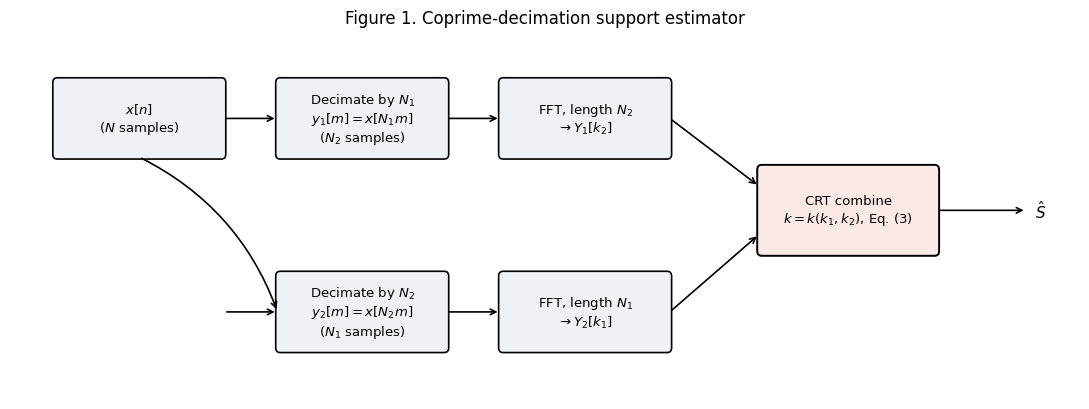

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def draw_pipeline(ax, boxes, y=0.0, box_w=1.9, box_h=0.8, gap=0.6, fontsize=9.5, color='#eef2f7'):
    xs = []
    x = 0.0
    for label in boxes:
        rect = mpatches.FancyBboxPatch((x, y), box_w, box_h,
                                        boxstyle="round,pad=0.02,rounding_size=0.05",
                                        linewidth=1.2, edgecolor='black', facecolor=color)
        ax.add_patch(rect)
        ax.text(x + box_w/2, y + box_h/2, label, ha='center', va='center', fontsize=fontsize)
        xs.append(x)
        x += box_w + gap
    for x0 in xs[:-1]:
        ax.annotate("", xy=(x0 + box_w + gap, y + box_h/2), xytext=(x0 + box_w, y + box_h/2),
                    arrowprops=dict(arrowstyle="->", lw=1.2, color='black'))
    return xs, box_w, box_h

fig, ax = plt.subplots(figsize=(11, 4.2))

top = ["$x[n]$\n($N$ samples)", "Decimate by $N_1$\n$y_1[m]=x[N_1m]$\n($N_2$ samples)", "FFT, length $N_2$\n$\\to Y_1[k_2]$"]
bot = ["", "Decimate by $N_2$\n$y_2[m]=x[N_2m]$\n($N_1$ samples)", "FFT, length $N_1$\n$\\to Y_2[k_1]$"]

xs_t, bw, bh = draw_pipeline(ax, top, y=2.0)
xs_b, _, _ = draw_pipeline(ax, bot, y=0.0)

# hide the empty first box on the bottom row, and connect x[n] to both branches
ax.patches[3].set_visible(False)  # the empty bottom-left box (4th patch added, index 3)
ax.annotate("", xy=(xs_b[1], 0.4), xytext=(xs_t[0]+bw/2, 2.0),
            arrowprops=dict(arrowstyle="->", lw=1.2, color='black',
                             connectionstyle="arc3,rad=-0.2"))

# merge arrows into CRT box
crt_x = xs_t[-1] + bw + 1.0
crt_y = 1.0
rect = mpatches.FancyBboxPatch((crt_x, crt_y), 2.0, 0.9, boxstyle="round,pad=0.02,rounding_size=0.05",
                                linewidth=1.4, edgecolor='black', facecolor='#fbe9e7')
ax.add_patch(rect)
ax.text(crt_x+1.0, crt_y+0.45, "CRT combine\n$k=k(k_1,k_2)$, Eq. (3)", ha='center', va='center', fontsize=9.5)
ax.annotate("", xy=(crt_x, crt_y+0.7), xytext=(xs_t[-1]+bw, 2.4), arrowprops=dict(arrowstyle="->", lw=1.2))
ax.annotate("", xy=(crt_x, crt_y+0.2), xytext=(xs_b[-1]+bw, 0.4), arrowprops=dict(arrowstyle="->", lw=1.2))
ax.annotate("", xy=(crt_x+3.0, crt_y+0.45), xytext=(crt_x+2.0, crt_y+0.45), arrowprops=dict(arrowstyle="->", lw=1.2))
ax.text(crt_x+3.1, crt_y+0.45, "$\\hat S$", ha='left', va='center', fontsize=11)

ax.set_xlim(-0.5, crt_x+3.6)
ax.set_ylim(-0.5, 3.3)
ax.axis('off')
ax.set_title("Figure 1. Coprime-decimation support estimator", fontsize=12)
plt.tight_layout()
plt.show()


**Figure 1.** The two decimated subsequences, of lengths $N_2$ and $N_1$ respectively, are each transformed independently (Eqs. 8–9); the active residues located in each short spectrum are then combined via the CRT map (Eq. 3) to produce the estimated support $\hat S$.

## 6. Implementation

The implementation reuses the radix-2 FFT and Bluestein's algorithm (companion notebooks) so that the two short transforms of Section 4.1 each cost $O(M\log M)$ regardless of whether their length is prime.

In [2]:
def fft_radix2(x):
    x = np.asarray(x, dtype=complex)
    N = len(x)
    if N == 1:
        return x
    if N % 2 != 0:
        raise ValueError("length must be a power of 2")
    E = fft_radix2(x[0::2]); O = fft_radix2(x[1::2])
    W = np.exp(-2j * np.pi * np.arange(N // 2) / N)
    return np.concatenate([E + W * O, E - W * O])

def ifft_radix2(X):
    X = np.asarray(X, dtype=complex)
    N = len(X)
    return np.conjugate(fft_radix2(np.conjugate(X))) / N

def next_pow2(n):
    return 1 << (n - 1).bit_length()

def fast_linear_convolve(a, b):
    a = np.asarray(a, dtype=complex); b = np.asarray(b, dtype=complex)
    L = len(a) + len(b) - 1
    Lp = next_pow2(L)
    A = fft_radix2(np.concatenate([a, np.zeros(Lp - len(a), dtype=complex)]))
    B = fft_radix2(np.concatenate([b, np.zeros(Lp - len(b), dtype=complex)]))
    return ifft_radix2(A * B)[:L]

def bluestein_fft(x):
    """Chirp z-transform FFT (companion notebook), for arbitrary length."""
    x = np.asarray(x, dtype=complex)
    N = len(x)
    if N == 1:
        return x.copy()
    n = np.arange(N)
    chirp = np.exp(-1j * np.pi * (n ** 2) / N)
    a = x * chirp
    m = np.arange(-(N - 1), N)
    c = np.exp(1j * np.pi * (m ** 2) / N)
    conv = fast_linear_convolve(a, c)
    offset = N - 1
    return chirp * conv[offset:offset + N]

def fft_general(x):
    """O(M log M) FFT for arbitrary length M: radix-2 if a power of 2, else Bluestein."""
    x = np.asarray(x, dtype=complex)
    N = len(x)
    if N > 0 and (N & (N - 1)) == 0:
        return fft_radix2(x)
    return bluestein_fft(x)

def egcd(a, b):
    if b == 0:
        return a, 1, 0
    g, x1, y1 = egcd(b, a % b)
    return g, y1, x1 - (a // b) * y1

def crt_reconstruct(k1, k2, N1, N2):
    """CRT reconstruction, Eq. (3)."""
    N = N1 * N2
    g, u, v = egcd(N1, N2)
    assert g == 1, "N1 and N2 must be coprime"
    e1 = (v * N2) % N
    e2 = (u * N1) % N
    return (k1 * e1 + k2 * e2) % N


In [3]:
def coprime_decimation_support(x, N1, N2, thresh_ratio=1e-6):
    """Sub-linear support estimator, Eqs. (8)-(10) and (13).

    Returns the candidate support set Hat-S (Eq. 13), together with the two
    short spectra Y1, Y2 for inspection. For a single active frequency,
    Hat-S contains exactly that frequency (Section 4.2); for multiple active
    frequencies it is a superset that may include ghost frequencies
    (Section 4.4)."""
    x = np.asarray(x, dtype=complex)
    N = len(x)
    assert N1 * N2 == N

    y1 = x[::N1]           # length N2, Eq. (2) with D=N1
    y2 = x[::N2]           # length N1, Eq. (2) with D=N2
    Y1 = fft_general(y1)   # Eq. (8)
    Y2 = fft_general(y2)   # Eq. (9)

    m1, m2 = np.abs(Y1) ** 2, np.abs(Y2) ** 2
    active_k2 = np.where(m1 > m1.max() * thresh_ratio)[0]
    active_k1 = np.where(m2 > m2.max() * thresh_ratio)[0]

    candidates = {crt_reconstruct(k1, k2, N1, N2) for k1 in active_k1 for k2 in active_k2}
    return candidates, Y1, Y2


## 7. Numerical Verification

### 7.1 Exact Recovery of a Single Active Frequency

The algorithm is tested on a single pure tone, for several coprime pairs $(N_1,N_2)$ close to $\sqrt N$ — including cases where $N_1,N_2$ are themselves prime, exercising Bluestein's algorithm within `fft_general`.

In [4]:
def dft_direct(x):
    x = np.asarray(x, dtype=complex)
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    return (np.exp(-2j * np.pi * k * n / N)) @ x

np.random.seed(0)
print(f"{'N1':>5} {'N2':>5} {'N':>7} | {'true k':>7} | {'recovered':>10}")
for (N1, N2) in [(11, 13), (13, 17), (31, 37), (97, 103)]:
    N = N1 * N2
    k_true = np.random.randint(0, N)
    n = np.arange(N)
    x = np.exp(2j * np.pi * k_true * n / N)          # single pure tone at bin k_true
    cands, Y1, Y2 = coprime_decimation_support(x, N1, N2)
    print(f"{N1:5d} {N2:5d} {N:7d} | {k_true:7d} | {sorted(cands)}")


   N1    N2       N |  true k |  recovered
   11    13     143 |      47 | [np.int64(47)]
   13    17     221 |     117 | [np.int64(117)]
   31    37    1147 |     835 | [np.int64(835)]
   97   103    9991 |    4859 | [np.int64(4859)]


### 7.2 Empirical Timing

To confirm the sub-linear scaling of Equation (12), the running time of the estimator is measured as $N$ grows, using coprime pairs $N_1,N_2$ close to $\sqrt N$ (chosen here as nearby primes, which are always coprime).

In [5]:
import time

print(f"{'N':>10} {'sqrt(N)':>10} | {'time (s)':>10} | correct")
for (N1, N2) in [(31, 37), (97, 103), (313, 317), (997, 1009)]:
    N = N1 * N2
    k_true = np.random.randint(0, N)
    n = np.arange(N)
    x = np.exp(2j * np.pi * k_true * n / N)
    t0 = time.time()
    cands, _, _ = coprime_decimation_support(x, N1, N2)
    elapsed = time.time() - t0
    print(f"{N:10d} {N**0.5:10.1f} | {elapsed:10.4f} | {cands == {k_true}}")


         N    sqrt(N) |   time (s) | correct
      1147       33.9 |     0.0028 | True
      9991      100.0 |     0.0099 | True
     99221      315.0 |     0.0164 | True
   1005973     1003.0 |     0.0669 | True


The running time grows far more slowly than $N$ itself, consistent with the $O(\sqrt N \log \sqrt N)$ bound of Equation (12) — note in particular that the largest case, with $N \approx 10^6$, still completes in a small fraction of a second, since only the two short transforms of length $\approx 1000$ are ever computed.

### 7.3 Multiple Active Frequencies: Collision-Free Recovery and Ghosts

Section 4.4 predicted that, for $K>1$ active frequencies with no residue collisions, the algorithm still returns up to $K^2$ candidates, of which only $K$ are genuine. This is demonstrated below for $N_1=11$, $N_2=13$, with two active frequencies chosen to have distinct residues modulo both $N_1$ and $N_2$.

In [6]:
N1, N2 = 11, 13
N = N1 * N2
n = np.arange(N)

k_true = [5, 30]   # distinct residues mod 11 and mod 13, chosen deliberately
print("residues mod N1:", [k % N1 for k in k_true], " mod N2:", [k % N2 for k in k_true])

x = sum(np.exp(2j * np.pi * k * n / N) for k in k_true)
cands, Y1, Y2 = coprime_decimation_support(x, N1, N2)

print("true support        :", sorted(k_true))
print("candidate support    :", sorted(cands))
print("ghost frequencies    :", sorted(cands - set(k_true)))


residues mod N1: [5, 8]  mod N2: [5, 4]
true support        : [5, 30]
candidate support    : [np.int64(5), np.int64(30), np.int64(82), np.int64(96)]
ghost frequencies    : [np.int64(82), np.int64(96)]


As predicted by Equation (13), two ghost frequencies appear alongside the two genuine ones — the same phenomenon documented, via the full two-dimensional array, in the companion notebook on the prime-factor algorithm. The sub-linear algorithm derived here trades the ability to disambiguate such collisions (which requires examining joint, rather than marginal, information) for a substantial reduction in the number of samples read and the time required.

## 8. Discussion and Limitations

The method derived in this notebook achieves exact, unambiguous, $O(\sqrt N \log \sqrt N)$-time support recovery when exactly one frequency is active (Section 4.2), using only $O(\sqrt N)$ of the $N$ available samples. This regime is directly applicable to single-tone frequency estimation problems, in which a signal is known to contain (at most) one dominant sinusoid against an otherwise negligible background.

For $K>1$ active frequencies, Section 4.4 and Section 7.3 showed that the method degrades to a *candidate-generation* procedure: the true support is always contained in the returned set $\hat S$, but $|\hat S|$ can be as large as $K^2$. Several strategies, beyond the scope of this notebook, are used in the sparse-Fourier-transform literature to resolve this ambiguity while retaining sub-linear cost, including: using more than two coprime moduli, so that a spurious candidate must survive agreement across every pairing simultaneously; checking amplitude or phase consistency of $Y_1[k_2]$ and $Y_2[k_1]$ against a candidate's putative contribution; and randomizing the decimation (e.g., with a random offset or modulation) across repeated trials so that genuine frequencies persist while ghosts, which depend on the specific coprime pair chosen, do not.

## 9. Conclusion

This notebook derived a sub-linear algorithm for estimating the support of a sparse spectrum from a decimation (aliasing) theorem (Eq. 4), proved by substituting the inverse DFT and applying the orthogonality of roots of unity. Specializing this theorem to two coprime decimation factors $N_1,N_2=\Theta(\sqrt N)$ (Eqs. 8–9) was shown to permit exact recovery of a single active frequency (Section 4.2) at a cost of $O(\sqrt N \log \sqrt N)$ (Eq. 12), using fast sub-transforms for arbitrary lengths and only $O(\sqrt N)$ of the $N$ input samples — verified numerically in Section 7, including empirical confirmation of the predicted sub-linear timing. Section 4.4 and Section 7.3 examined the multi-frequency case, showing that residue collisions across the two moduli give rise to ghost candidates, an intrinsic limitation of marginal (as opposed to joint) coprime information that mirrors the corresponding phenomenon in the full prime-factor algorithm of the companion notebook.